<a href="https://colab.research.google.com/github/JOliveiraLemos/auc-consistency-analysis-banking/blob/main/auc_concistency_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 ## 1. Introduction

This project analyzes inconsistencies between financial data sources (custody, accounting, and transactions) to build a reliable Assets Under Custody (AUC) metric.

The goal is to detect errors, understand data quality issues, and evaluate asset evolution over time. In addition, a comparison of total assets under custody with competitors (also simulated data) will be conducted to assess the institution’s market position. This type of analytical framework is important both for assessing how a lack of integration or system errors can impact the financial institution’s positioning relative to competitors in the analysis of assets under custody, and for understanding how the analytical tools and metrics defined here can contribute to the repositioning of a financial institution.

##2. Data Source

The dataset was synthetically generated using SQL scripts to simulate a financial environment, including:

- Transactions (cash flow)
- Custody balances (assets)
- Accounting balances
- Competitor data (Total AUC/ monthly)

Data was exported to CSV and analyzed using Python.

## 3. How to Run

### 1. Run SQL scripts to generate data
### 2. Export to CSV
### 3. Run notebook

## 4. Data Loading


In [43]:
# Data Loading
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import plotly.express as px
import plotly.graph_objects as go

In [44]:
df = pd.read_csv('/content/drive/MyDrive/AUC.csv')
df['data'] = pd.to_datetime(df['data'], format= '%Y-%m-%d')
df.rename(columns={
    'id_cliente': 'customer_id',
    'id_produto': 'product_id',
    'saldo_custodia': 'custody_balance',
    'saldo_contabil': 'accounting_balance',
    'saldo_movimentado': 'movement_balance',
    'data': 'date'}, inplace = True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   customer_id         150 non-null    int64         
 1   product_id          150 non-null    int64         
 2   date                150 non-null    datetime64[ns]
 3   custody_balance     150 non-null    float64       
 4   accounting_balance  150 non-null    float64       
 5   movement_balance    150 non-null    float64       
dtypes: datetime64[ns](1), float64(3), int64(2)
memory usage: 7.2 KB


In [45]:
df.head()

,customer_id,product_id,date,custody_balance,accounting_balance,movement_balance
0,17,1,2025-03-25,2193.37,1964.26,370.45
1,38,1,2025-05-30,1000.52,797.56,1000.52
2,43,1,2025-04-29,1500.09,1579.99,847.09
3,46,1,2025-06-08,138.41,303.00,138.41
4,34,1,2025-01-25,804.99,619.12,804.99


## 5. Data Preparation

In [46]:
df= df.sort_values(by='date')
df.head()

,customer_id,product_id,date,custody_balance,accounting_balance,movement_balance
133,43,3,2025-01-03,-3937.15,-3811.85,-3937.15
36,41,2,2025-01-04,4652.47,4704.82,4652.47
54,31,3,2025-01-08,3991.84,3834.19,3991.84
118,32,2,2025-01-08,-994.35,-985.03,-994.35
140,14,3,2025-01-09,-4984.97,-4793.30,-4984.97


## 6. Feature Engineering

In [47]:
## Feature Engineering

#New metrics were created to compare balance variations and detect inconsistencies between systems.
#To identify non-standard balance variations that may occur due to systemic inconsistencies, the pct_change() metric was used,
#which calculates the percentage change between consecutive elements in a series, thereby comparing the current row with the previous one.
#This also makes it possible to verify whether there are discrepancies between records in the custody and accounting systems

#In this regard, the balances recorded in the custody and accounting systems should be the same—or show only minor discrepancies—and
#the current day’s transaction balance should be proportional to the custody balance recorded the previous day; in other words,
#it would not make sense for a customer to conduct transactions exceeding the amount held in custody. Thus, the following three metrics were defined:

# 1 - percentage change in the custody balance (pct_delta_custody)
# 2 - percentage change in the accounting balance (pct_delta_acconting)
# 3 - and percentage change in transactions based on the previous day’s custody record (pct_movement_vs_custody)


# Sort by customer_id and date to ensure correct sequential calculation within each client group

df = df.sort_values(by=['customer_id', 'date'])

# Calculate pct_change() grouped by customer_id

df['pct_delta_custody'] = df.groupby('customer_id')['custody_balance'].pct_change() * 100
df['pct_delta_acconting'] = df.groupby('customer_id')['accounting_balance'].pct_change() * 100

# Calculate pct_movimentacao_vs_custody grouped by customer_id
# Use groupby and transform to get the shifted value for each customer_id

shifted_saldo_custodia_per_client = df.groupby('customer_id')['custody_balance'].transform(lambda x: x.shift(1))
df['pct_movement_vs_custody'] = ((df['movement_balance'] / shifted_saldo_custodia_per_client) - 1) * 100


display(df.head())

,customer_id,product_id,date,custody_balance,accounting_balance,movement_balance,pct_delta_custody,pct_delta_acconting,pct_movement_vs_custody
62,1,3,2025-02-06,2212.12,2435.21,2212.12,NaN,NaN,NaN
26,1,2,2025-03-27,2068.07,2281.83,2068.07,-6.511853,-6.298430,-6.511853
12,1,1,2025-06-23,2608.34,2370.45,2608.34,26.124357,3.883725,26.124357
9,2,1,2025-01-19,776.81,994.32,776.81,NaN,NaN,NaN
32,2,2,2025-02-22,4039.58,3905.97,4039.58,420.021627,292.828265,420.021627


In [48]:


# Update the list of columns to plot to reflect the new percentage delta columns

delta_columns_to_plot_pct = ['pct_delta_custody', 'pct_movement_vs_custody', 'pct_delta_acconting']

fig_deltas = go.Figure()

for col_name in delta_columns_to_plot_pct:
    fig_deltas.add_trace(go.Scatter(
        x=df['date'],
        y=df[col_name],
        mode='markers',
        name=col_name.replace('_', ' ').title() # Title case for legend
    ))

fig_deltas.update_layout(
    title='Daily Percentage Change in Balances by Customer',
    xaxis_title='Date',
    yaxis_title='Percentage Change in Balance',
    hovermode='x unified'
)

fig_deltas.show()

In [49]:


# Create a figure for box plots in order to identify outliers, i.e, non-standard transactions

fig_box = px.box(df, y=delta_columns_to_plot_pct,
                 title='Box Plot of the Daily Percentage Change in Customer Balances',
                 labels={'value': 'Percentage Change in Balance', 'variable': 'type of balance'})

fig_box.update_layout(
    yaxis_title='Percentage Change in Balance',
    showlegend=True
)

fig_box.show()

In [50]:
#The presence of an outlier that is significantly larger in magnitude than the majority of transactions makes
#it difficult to visualize the behavior of those transactions. Therefore, to improve data visualization,
#the two largest outliers will be removed so that the data’s order of magnitude allows for better visualization.

min_delta_accounting = df['pct_delta_acconting'].min()
# Filter out the first minimum
df_filtered_step1 = df[df['pct_delta_acconting'] != min_delta_accounting].copy()

# Find the second minimum from the already filtered dataframe
min_delta_accounting_2 = df_filtered_step1['pct_delta_acconting'].min()

# Filter out the second minimum from the dataframe that already had the first minimum removed
df_filtered = df_filtered_step1[df_filtered_step1['pct_delta_acconting'] != min_delta_accounting_2].copy()

delta_columns_to_plot_pct = ['pct_delta_custody', 'pct_movement_vs_custody', 'pct_delta_acconting']

fig_deltas = go.Figure()

for col_name in delta_columns_to_plot_pct:
    # Use the final filtered DataFrame for plotting
    fig_deltas.add_trace(go.Scatter(
        x=df_filtered['date'],
        y=df_filtered[col_name],
        mode='markers',
        name=col_name.replace('_', ' ').title() # Title case for legend
    ))

fig_deltas.update_layout(
    title='Daily Percentage Change in Balances by Customer (Outliers Removed)',
    xaxis_title='Date',
    yaxis_title='Percentage Change in Balance',
    hovermode='x unified'
)

fig_deltas.show()

## 7. Anomaly Detection

In [51]:

##Anomalies were defined based on three main criteria:

#- System inconsistency: mismatch between custody and accounting balances
#- Movement anomaly: unusually large transactions compared to balance
#- Low base effect: distortions caused by small denominators

# Initialize error columns with a default value 'normal' for all rows
df['system_anomaly'] = 'normal'
df['movement_anomaly'] = 'normal'
df['low_base_effect_anomaly'] = 'normal' # New error column

# Define conditions

# 1- Condition for discrepancy systems: differences between the custody balance and the accounting balance,
#or values with different signs between the records in the custody and accounting systems

cond_system_divergence = ((df['custody_balance'] < 0) & (df['accounting_balance'] > 0)) | \
                          ((df['accounting_balance'] < 0) & (df['custody_balance'] > 0))

cond_system_magnitude = ((np.abs(df['accounting_balance'] - df['custody_balance']) > 0.1 * np.abs(df['custody_balance'])) & \
                          (np.abs(df['accounting_balance'] - df['custody_balance']) > 100))

full_cond_error_system = cond_system_divergence | cond_system_magnitude

# Apply 'error_system' flag
df.loc[full_cond_error_system, 'system_anomaly'] = 'discrepancy systems'

# 2 - Condition for 'low_base_effect_error'because division by very small numbers results in large percentages
# If custody_balance is below 5% of its absolute distribution

low_base_threshold = df['custody_balance'].abs().quantile(0.05)
cond_low_base_effect = (df['custody_balance'].abs() < low_base_threshold)

# Apply 'error_low_base_effect' flag
df.loc[cond_low_base_effect, 'low_base_effect_anomaly'] = 'Low Base Effect'


# Condition for 'moviment_error'
# Based on 95th percentile for high values and not a higher priority anomaly
# Interpretation: 'unusual transaction' are values above which only 5% of the data lies (i.e., > 95th percentile).

mov_pattern_threshold = df['pct_movement_vs_custody'].quantile(0.95)
cond_error_movement = \
    (df['pct_movement_vs_custody'] > mov_pattern_threshold) & \
    ~cond_low_base_effect


# Apply 'error_movement' flag
df.loc[cond_error_movement, 'movement_anomaly'] = 'unusual transaction'

In [52]:
df.head()

,customer_id,product_id,date,custody_balance,accounting_balance,movement_balance,pct_delta_custody,pct_delta_acconting,pct_movement_vs_custody,system_anomaly,movement_anomaly,low_base_effect_anomaly
62,1,3,2025-02-06,2212.12,2435.21,2212.12,NaN,NaN,NaN,discrepancy systems,normal,normal
26,1,2,2025-03-27,2068.07,2281.83,2068.07,-6.511853,-6.298430,-6.511853,discrepancy systems,normal,normal
12,1,1,2025-06-23,2608.34,2370.45,2608.34,26.124357,3.883725,26.124357,normal,normal,normal
9,2,1,2025-01-19,776.81,994.32,776.81,NaN,NaN,NaN,discrepancy systems,normal,normal
32,2,2,2025-02-22,4039.58,3905.97,4039.58,420.021627,292.828265,420.021627,normal,unusual transaction,normal


In [53]:
#After applying the anomaly conditions to the transactions, charts will be generated to show
# percentage of normal transactions and those with anomalies, as well as the most common types of anomalies

# Define the anomalies columns
anomaly_columns = ['system_anomaly', 'movement_anomaly',  'low_base_effect_anomaly']

# Calculate the number of anomaly for each row
df['num_anomaly'] = df[anomaly_columns].apply(lambda x: (x != 'normal').sum(), axis=1)

# Categorize rows based on the number of anomalies

def categorize_anomaly_counts(row):
    if row['num_anomaly'] == 0:
        return 'normal'
    elif row['num_anomaly'] == 1:
        return '1 type of anomaly'
    elif row['num_anomaly'] == 2:
        return '2 type of anomaly'
    else: # row['num_anomaly'] == 3 or more
        return '3 type of anomaly'

df['category_anomaly'] = df.apply(categorize_anomaly_counts, axis=1)

# Calculate counts and percentages for each category

category_counts = round(df['category_anomaly'].value_counts(normalize=True).mul(100).reset_index(),2)
category_counts.columns = ['category', 'Percent']

# Sort categories for better visualization

category_order = ['normal', '1 type of anomaly', '2 type of anomaly', '3 type of anomaly']
category_counts['category'] = pd.Categorical(category_counts['category'], categories=category_order, ordered=True)
category_counts = category_counts.sort_values('category')

# Plot the distribution of anomalies categories

fig_category = px.bar(
    category_counts,
    x='category',
    y='Percent',
    title='Category distribution transaction anomaly',
    labels={'Category': 'Number of type of anomaly', 'Percent': 'lines percent (%)'},
    text_auto=True # Display percentage values on bars
)
fig_category.update_layout(yaxis_range=[0, category_counts['Percent'].max() * 1.1]) # Adjust y-axis range
fig_category.show()

In [54]:
# Identify and count specific recurrent anomaly types
specific_anomaly_data = {
    'Type of anomaly': [],
    'Count': [],
    'Percent': []
}

# Define the errors columns '
anomaly_columns = ['system_anomaly', 'movement_anomaly', 'low_base_effect_anomaly']

# Count occurrences of each specific anomaly type string
for col_name in anomaly_columns:
    # Get unique non-'normal' values from the current anomaly column
    anomaly_in_col = df[df[col_name] != 'normal'][col_name].unique()
    for anomaly_type in anomaly_in_col:
        count = (df[col_name] == anomaly_type).sum()
        if count > 0: # Only add if there are occurrences
            specific_anomaly_data['Type of anomaly'].append(anomaly_type)
            specific_anomaly_data['Count'].append(count)
            # Apply round to the calculated percentage before appending
            specific_anomaly_data['Percent'].append(round((count / len(df)) * 100, 2))

# Create a DataFrame from the collected data
specific_anomaly_df = pd.DataFrame(specific_anomaly_data)

# Sort by percentage to show most recurrent first
specific_anomaly_df = specific_anomaly_df.sort_values(by='Percent', ascending=False)

# Plot the most recurrent anomaly types
fig_specific = px.bar(
    specific_anomaly_df,
    x='Type of anomaly',
    y='Percent',
    title='Common anomalies considering total lines %',
    labels={'Type of anomaly': 'anomaly', 'Percent': 'Line Perncent (%)'},
    text_auto=True # Display percentage values on bars
)
fig_specific.update_layout(yaxis_range=[0, specific_anomaly_df['Percent'].max() * 1.1]) # Adjust y-axis range
fig_specific.show()

In [55]:
#Mean absolute error between custody system and accounting system

from sklearn.metrics import mean_absolute_error
mean_absolute_error(df['custody_balance'], df['accounting_balance'])

127.4588

## 8. AUC Construction

In [56]:
## AUC Construction - To track changes in the assets held in custody by the institution and subsequently compare them
#with those of competitors in the market, the following procedure was adopted, taking into account the inconsistencies identified in the previous sections:


##The adjusted AUC was calculated prioritizing custody balance when consistent, falling back to accounting balance when necessary,
# and excluding unreliable cases, i. e., custody_balance ==0 then will not be included in the montlhy total.

##This approach aims to mitigate inconsistencies across data sources.

# Define the conditions and corresponding choices

df_auc = df.loc[:, ['date', 'product_id','custody_balance', 'accounting_balance']]
df_auc = df_auc.sort_values('date')
df_auc.head()

,date,product_id,custody_balance,accounting_balance
133,2025-01-03,3,-3937.15,-3811.85
36,2025-01-04,2,4652.47,4704.82
54,2025-01-08,3,3991.84,3834.19
118,2025-01-08,2,-994.35,-985.03
140,2025-01-09,3,-4984.97,-4793.30


In [57]:
# Apply the condiction
conditions = [
    df_auc['custody_balance'] > 0,
    (df_auc['custody_balance'] < 0) & (df_auc['custody_balance'] > 0),
    (df_auc['custody_balance'] < 0) & (df_auc['custody_balance'] < 0)]

choices = [
    df_auc['custody_balance'],
    df_auc['accounting_balance'],
    0
]

# Use np.select to apply the conditions and choices
# Default value will be 0 if none of the conditions are met
df_auc['adjusted_AUC'] = np.select(conditions, choices, default=0)

df_auc

,date,product_id,custody_balance,accounting_balance,adjusted_AUC
133,2025-01-03,3,-3937.15,-3811.85,0.00
36,2025-01-04,2,4652.47,4704.82,4652.47
54,2025-01-08,3,3991.84,3834.19,3991.84
118,2025-01-08,2,-994.35,-985.03,0.00
140,2025-01-09,3,-4984.97,-4793.30,0.00
...,...,...,...,...,...
12,2025-06-23,1,2608.34,2370.45,2608.34
122,2025-06-26,2,-4926.18,-4794.42,0.00
125,2025-06-28,3,-5056.42,-4812.21,0.00
10,2025-06-28,1,2278.93,2521.55,2278.93


## 9. Exploratory Analysis

In [58]:
#After applying the selection criteria for the assets-in-custody record, a table was generated with
# a new column titled “adjusted assets-in-custody” (adjusted_AUC), which will be used for future analyses

#Generate a dataframe based on the sum of the monthly total of assets held in custody by the institution,
#regardless of asset type, to show trends

df_monthly_auc = df_auc.groupby(df_auc['date'].dt.to_period('M'))['adjusted_AUC'].sum().reset_index()
df_monthly_auc['date'] = df_monthly_auc['date'].dt.to_timestamp()
df_monthly_auc.rename(columns={'adjusted_AUC': 'total_AUC'}, inplace=True)

display(df_monthly_auc.head())

,date,total_AUC
0,2025-01-01,39533.62
1,2025-02-01,45422.69
2,2025-03-01,17219.17
3,2025-04-01,23798.60
4,2025-05-01,21632.43


<Axes: xlabel='Month', ylabel='Montlhy total AUC'>

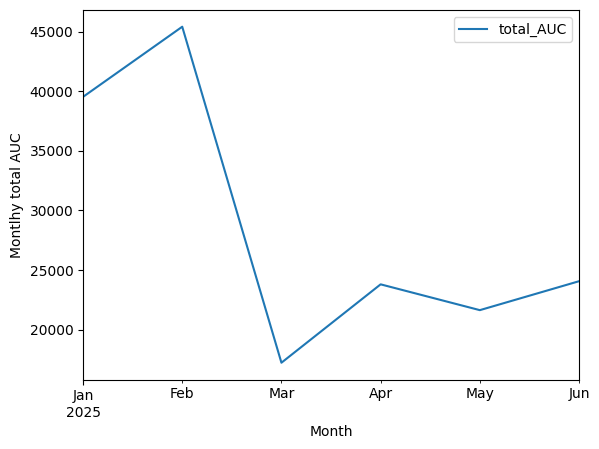

In [59]:
### Monthly AUC Evolution

df_monthly_auc.plot(x= 'date', y= 'total_AUC', xlabel= 'Month', ylabel = 'Montlhy total AUC')

In [60]:
#The results show a significant variation in AUC over time,
#possibly driven by data inconsistencies or missing data.

In [61]:
#Montlhy AUC Evolutino by type of assets in order to identify A chart showing the overall trend in assets by asset type, in order
#to track how each asset type has performed over the months, as well as those with the highest share

# Map product IDs to asset types
product_id_map = {
    1: 'Fixed',
    2: 'Founds',
    3: 'shares'
}

# Calculate monthly AUC_ajustado by product
df_product_monthly = df_auc.groupby([df['date'].dt.to_period('M'), 'product_id'])['adjusted_AUC'].sum().reset_index()

# Convert 'data' column back to datetime objects for plotting
df_product_monthly['date'] = df_product_monthly['date'].dt.to_timestamp()

# Add a column for 'Tipo de Ativo' (Asset Type)
df_product_monthly['asset_type'] = df_product_monthly['product_id'].map(product_id_map)


display(df_product_monthly.head())

,date,product_id,adjusted_AUC,asset_type
0,2025-01-01,1,10322.33,Fixed
1,2025-01-01,2,21099.07,Founds
2,2025-01-01,3,8112.22,shares
3,2025-02-01,1,9156.81,Fixed
4,2025-02-01,2,14099.45,Founds


In [62]:


# Calculate monthly total adjusted_AUC
df_monthly_total = df_product_monthly.groupby('date')['adjusted_AUC'].sum().reset_index()
df_monthly_total.rename(columns={'adjusted_AUC': 'montlhy_auc_total'}, inplace=True)

# Merge monthly total back to the product monthly dataframe
df_product_monthly_pct = pd.merge(df_product_monthly, df_monthly_total, on='date', how='left')

# Calculate percentage of each asset type per month
df_product_monthly_pct['auc_%'] = (df_product_monthly_pct['adjusted_AUC'] / df_product_monthly_pct['montlhy_auc_total']) * 100

# Create the stacked bar chart for percentage contribution
fig_product_pct = px.bar(
    df_product_monthly_pct,
    x='date',
    y='auc_%',
    color='asset_type',
    title='Monthly Breakdown of Adjusted AUC by Asset Type %',
    labels={'date': 'Month', 'auc_%': 'Percent', 'asset_type': 'asset_type'},
    hover_data={'asset_type': True, 'auc_%': ':.2f', 'adjusted_AUC': ':.2f'},
    text_auto='.2f' # Display percentage values, rounded to 2 decimal places
)

fig_product_pct.update_layout(
    xaxis_title='Month',
    yaxis_title='Percent Adjusted AUC (%)',
    yaxis_range=[0, 100] # Ensure y-axis goes from 0 to 100%
)

# Update text properties: position and font size
fig_product_pct.update_traces(textposition='inside', textfont_size=12)

fig_product_pct.show()

In [63]:
#The bar chart makes it possible to analyze the weight of each asset month by month in comparison with the others,
#thereby tracking growth #and identifying which assets are most popular with customers or which ones might be worth focusing on more,
#depending on the customers' profiles

### 8.1 Comparison with simulated public data from a competitor

In [64]:


# Ensure df_concorrentes is loaded, as it might not have been executed previously or its state was lost.
df_competitor = pd.read_csv('/content/drive/MyDrive/concorrentes.csv')
df_competitor = df_competitor.sort_values('data')



df_competitor.rename(columns={
    'data': 'date',
    'auc_total': 'competitor_auc_total'
}, inplace=True)
df_competitor.sort_values('date', inplace=True)
df_competitor

,date,competitor_auc_total
4,2025-01-01,1.261525e+06
1,2025-02-01,1.074640e+06
3,2025-03-01,1.075616e+06
2,2025-04-01,1.373833e+06
5,2025-05-01,1.300541e+06
0,2025-06-01,1.056656e+06


In [65]:


# Ensure 'date' column in df_concorrentes is also datetime for proper merge
df_competitor['date'] = pd.to_datetime(df_competitor['date'])

# Merge df_monthly_auc with df_concorrentes
df_comparison = pd.merge(df_monthly_auc, df_competitor, on='date', how='left')

# Rename columns as requested after merge
df_comparison.rename(columns={'adjusted_AUC': 'auc_total'}, inplace=True)

print('\nMerged DataFrame for comparison with renamed columns:')
display(df_comparison.head())


Merged DataFrame for comparison with renamed columns:


,date,total_AUC,competitor_auc_total
0,2025-01-01,39533.62,1.261525e+06
1,2025-02-01,45422.69,1.074640e+06
2,2025-03-01,17219.17,1.075616e+06
3,2025-04-01,23798.60,1.373833e+06
4,2025-05-01,21632.43,1.300541e+06


In [66]:



# Apply normalization in order to compare since magnitude order is large. We dont have the cosutmer numbers of competitor
df_comparison['norm_auc_total'] = df_comparison['total_AUC']/ df_comparison['total_AUC'][0]
df_comparison['norm_comp_auc_total'] = df_comparison['competitor_auc_total']/ df_comparison['competitor_auc_total'][0]


display(df_comparison.head())

,date,total_AUC,competitor_auc_total,norm_auc_total,norm_comp_auc_total
0,2025-01-01,39533.62,1.261525e+06,1.000000,1.000000
1,2025-02-01,45422.69,1.074640e+06,1.148964,0.851858
2,2025-03-01,17219.17,1.075616e+06,0.435558,0.852631
3,2025-04-01,23798.60,1.373833e+06,0.601984,1.089026
4,2025-05-01,21632.43,1.300541e+06,0.547191,1.030927


In [67]:


fig_pct_change = go.Figure()

fig_pct_change.add_trace(go.Scatter(
    x=df_comparison['date'],
    y=df_comparison['norm_auc_total'],
    mode='lines+markers',
    name='AUC normalized',
    hovertemplate='Data: %{x}<br>Minha AUC % Variação: %{y:.2f}%'
))

fig_pct_change.add_trace(go.Scatter(
    x=df_comparison['date'],
    y=df_comparison['norm_comp_auc_total'],
    mode='lines+markers',
    name='Competitor AUC normalized ',
    hovertemplate='Data: %{x}<br>Competitor AUC % change: %{y:.2f}%'
))

fig_pct_change.update_layout(
    title='Comparison of Monthly normalized Growth in AUC',
    xaxis_title='Month',
    yaxis_title=' normalized AUC monthly',
    hovermode='x unified'
)

fig_pct_change.show()

In [68]:
#The comparison chart with another database from a potential competitor allows us to see how well the institution has kept pace with growth.
# The sharp drop between February and March can be explained by missing data and inconsistencies that were removed, resulting in a lower monthly total.

## 10. Business Insights

In [69]:
## Business Insights

# - High level of inconsistency between systems
# - Accounting balance shows higher volatility
# - Significant number of anomalies detected (24%)
# - Data quality directly impacts AUC reliability

## 11. Conclusion

In [70]:
## Conclusion

#This analysis highlights the importance of data consistency in financial systems.

#The presence of anomalies and inconsistencies suggests the need for better integration between custody and accounting systems
#to ensure reliable asset reporting.